# Portfolio: from one strategy to a book

Section 2 ended with one strategy alive on paper, Crypto XS Momentum. This notebook answers the next question: **what is it worth to a book?** Then: how to combine, how to let a strategy in, and how to know when one has to leave.

| Part | Lesson | Sections |
|---|---|---|
| 1 | 3.1 What you trade is a portfolio | 1 |
| 2 | 3.2 The marginal Sharpe rule | 2 to 6 |
| 3 | 3.3 Combine simply | 7 to 9 |
| 4 | 3.4 Keep the portfolio alive | 10 to 11 |
| 5 | 3.5 Is the edge fading? | 12 to 16 |

**Data** (`data_portfolio/`)
- `portfolio_1_returns.csv`: a real crypto book, three strategies (Carry, Momentum, Low vol), daily net returns.
- `portfolio_2_returns.csv`: the same book without its Momentum strategy.
- `xs_momentum_returns.csv`: our candidate, the daily P&L of notebook 02.
- `fomc_drift_trades.csv`: the 117 trades of notebook 01.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data_portfolio"
PPY = 365                                   # crypto: one return per calendar day
ORANGE, GREY, BLUE = "#c8661f", "#9a958c", "#2f5d8a"
plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.grid": True, "grid.alpha": .3})

def sharpe(r, ppy=PPY):
    return r.mean() / r.std() * np.sqrt(ppy)

def equal_risk(df):
    """Equal risk weights: every strategy scaled to the same volatility, then averaged."""
    return (df / df.std()).mean(axis=1)

def cum_pct(r, vol=0.10, ppy=PPY):
    """Cumulative return in %, after scaling the series to `vol` annual volatility."""
    r = r / (r.std() * np.sqrt(ppy)) * vol
    return ((1 + r).cumprod() - 1) * 100

def drawdown(r):
    e = (1 + r).cumprod(); return e / e.cummax() - 1

# Part 1 · What you trade is a portfolio (lesson 3.1)

## 1. A 1.5 that adds nothing, a 0.5 that changes everything

Generated data, so every number is exact. A book of three strategies, Sharpe 1.0 each, correlated at 0.1. Two candidates:
- **A**: Sharpe 1.5, correlation 0.95 with the book. A near copy of what we already hold.
- **B**: Sharpe 0.5, correlation −0.3 with the book. Weak alone, but it moves when the book does not.

Each candidate is added at equal risk weight (1/4).

   Sharpe alone  corr. with book  book before  book after
A           1.5             0.95         1.58        1.57
B           0.5            -0.30         1.58        1.88


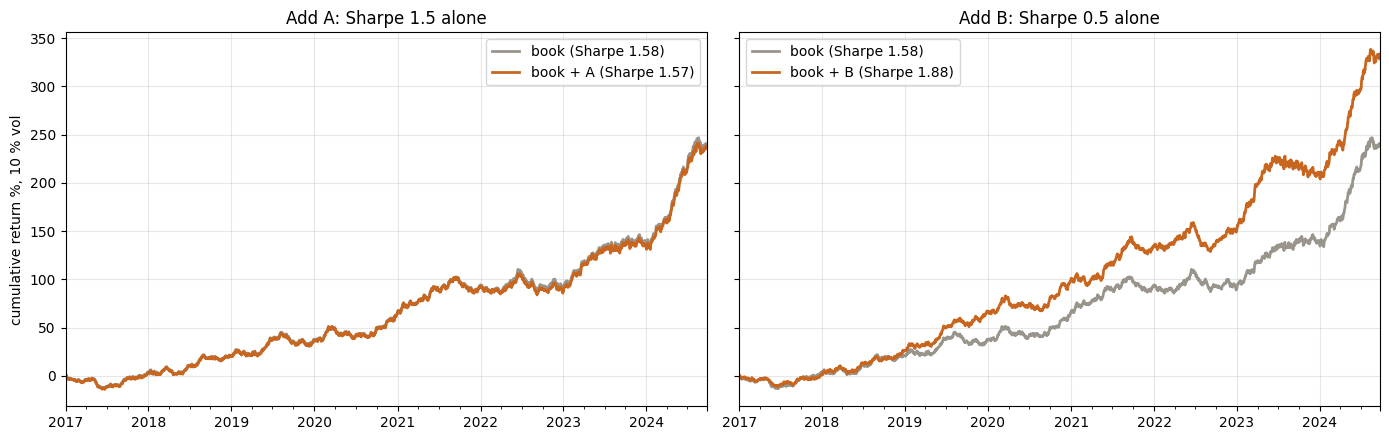

In [2]:
def exact_normals(rng, T, corr):
    """T draws whose sample correlation matrix is exactly `corr` (mean 0, std 1)."""
    X = rng.standard_normal((T, len(corr))); X -= X.mean(0)
    X = X @ np.linalg.inv(np.linalg.cholesky(np.cov(X.T, ddof=0))).T
    return X @ np.linalg.cholesky(corr).T

T, VOL = 252 * 8, 0.10
c, rho_A, rho_B = 0.1, 0.95, -0.3
k = np.sqrt((1 + 2 * c) / 3)                     # correlation of one strategy with the book
corr = np.full((5, 5), c); np.fill_diagonal(corr, 1)
corr[3, :3] = corr[:3, 3] = rho_A * k
corr[4, :3] = corr[:3, 4] = rho_B * k
corr[3, 4] = corr[4, 3] = rho_A * rho_B
X = exact_normals(np.random.default_rng(7), T, corr)
target_sr = np.array([1.0, 1.0, 1.0, 1.5, 0.5])
syn = pd.DataFrame(X * VOL / np.sqrt(252) + target_sr * VOL / 252,
                   columns=["S1", "S2", "S3", "A", "B"],
                   index=pd.bdate_range("2017-01-02", periods=T))

book = syn[["S1", "S2", "S3"]].mean(axis=1)
rows = {}
for cand in ["A", "B"]:
    new = syn[["S1", "S2", "S3", cand]].mean(axis=1)
    rows[cand] = {"Sharpe alone": sharpe(syn[cand], 252), "corr. with book": syn[cand].corr(book),
                  "book before": sharpe(book, 252), "book after": sharpe(new, 252)}
print(pd.DataFrame(rows).T.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for a, cand in zip(ax, ["A", "B"]):
    new = syn[["S1", "S2", "S3", cand]].mean(axis=1)
    cum_pct(book, ppy=252).plot(ax=a, color=GREY, lw=2, label=f"book (Sharpe {sharpe(book, 252):.2f})")
    cum_pct(new, ppy=252).plot(ax=a, color=ORANGE, lw=2, label=f"book + {cand} (Sharpe {sharpe(new, 252):.2f})")
    a.set_title(f"Add {cand}: Sharpe {target_sr[3 if cand == 'A' else 4]} alone"); a.legend(); a.set_ylabel("cumulative return %, 10 % vol")
plt.tight_layout(); plt.show()

**Read it.** A, the best strategy on paper, leaves the book where it was. B, the weakest, lifts it from 1.58 to 1.88. A strategy is never judged alone.

# Part 2 · The marginal Sharpe rule (lesson 3.2)

## 2. Two books, one candidate

Same candidate, Crypto XS Momentum, offered to two books:
- **Portfolio 1**: Carry, Momentum, Low vol.
- **Portfolio 2**: Carry, Low vol. The same book, without its momentum strategy.

We only use the dates where the three files overlap.

In [3]:
P1 = pd.read_csv(f"{DATA}/portfolio_1_returns.csv", index_col=0, parse_dates=True)
P2 = pd.read_csv(f"{DATA}/portfolio_2_returns.csv", index_col=0, parse_dates=True)
XS = pd.read_csv(f"{DATA}/xs_momentum_returns.csv", index_col=0, parse_dates=True)["total"].rename("XS Momentum")
XS = XS[XS.ne(0).idxmax():]                       # from its first trading day

BOOKS = {"Portfolio 1": P1, "Portfolio 2": P2}
DF = {name: P.join(XS, how="inner").dropna() for name, P in BOOKS.items()}
d = DF["Portfolio 1"]
print(f"{d.index[0]:%Y-%m-%d} -> {d.index[-1]:%Y-%m-%d}, {len(d)} days")
print(d.corr().round(2).to_string())

2021-06-29 -> 2026-08-24, 1883 days
             Carry  Momentum  Low vol  XS Momentum
Carry         1.00      0.33    -0.38         0.16
Momentum      0.33      1.00    -0.38         0.42
Low vol      -0.38     -0.38     1.00        -0.29
XS Momentum   0.16      0.42    -0.29         1.00


## 3. The rule

Adding a small slice of a new strategy raises the book's Sharpe if and only if

**Sharpe(new) > correlation(new, book) × Sharpe(book)**

The right side is the hurdle. A book that is already good sets a high hurdle for anything that looks like it, and almost no hurdle for anything that does not.

In [4]:
def marginal_rule(df, cols, cand="XS Momentum"):
    book = equal_risk(df[cols])
    rho = df[cand].corr(book)
    return pd.Series({"book Sharpe": sharpe(book), "candidate Sharpe": sharpe(df[cand]),
                      "correlation": rho, "hurdle": rho * sharpe(book),
                      "book + candidate, equal weight": sharpe(equal_risk(df[cols + [cand]]))})

rule = pd.DataFrame({name: marginal_rule(DF[name], list(P.columns)) for name, P in BOOKS.items()})
print(rule.round(2).to_string())

                                Portfolio 1  Portfolio 2
book Sharpe                            1.61         1.07
candidate Sharpe                       0.74         0.74
correlation                            0.20        -0.12
hurdle                                 0.32        -0.13
book + candidate, equal weight         1.61         1.38


**Read it.** The candidate passes both hurdles. But against Portfolio 1 it adds nothing at equal weight: it overlaps with the Momentum strategy already in the book. Against Portfolio 2 it lifts the Sharpe by about 0.3.

## 4. The trap: correlation in bad times

An average correlation can hide a strategy that loses exactly when the book loses. We look again, on the book's worst months only (bottom quarter).

In [5]:
def bad_times_corr(df, cols, cand="XS Momentum", q=0.25):
    m = df.resample("ME").sum()
    book = equal_risk(df[cols]).resample("ME").sum()
    bad = book < book.quantile(q)
    return pd.Series({"all months": m[cand].corr(book), "worst 25 % months": m.loc[bad, cand].corr(book[bad]),
                      "candidate mean in those months %": m.loc[bad, cand].mean() * 100})

print(pd.DataFrame({name: bad_times_corr(DF[name], list(P.columns)) for name, P in BOOKS.items()}).round(2).to_string())

                                  Portfolio 1  Portfolio 2
all months                               0.16        -0.21
worst 25 % months                        0.15        -0.24
candidate mean in those months %        -0.50         2.35


## 5. Better, or better by luck?

Five years is short. To see if the gain survives other plausible histories, we rewrite history 2,000 times (block bootstrap, as in lesson 2.7):
1. Cut the common history into blocks of 63 days (about two months). Blocks keep together the days that belong together.
2. Draw blocks at random, **with replacement**, until we have as many days as the real history. Some periods come out twice, some never: a different but plausible history.
3. On that history, Sharpe of the book without XS Momentum and with it, on the same days. Keep the gain.
4. Repeat 2,000 times. Count how often the gain is above zero.

                                 Portfolio 1  Portfolio 2
Sharpe gain                             -0.0         0.31
book improves in % of histories         62.2        91.00


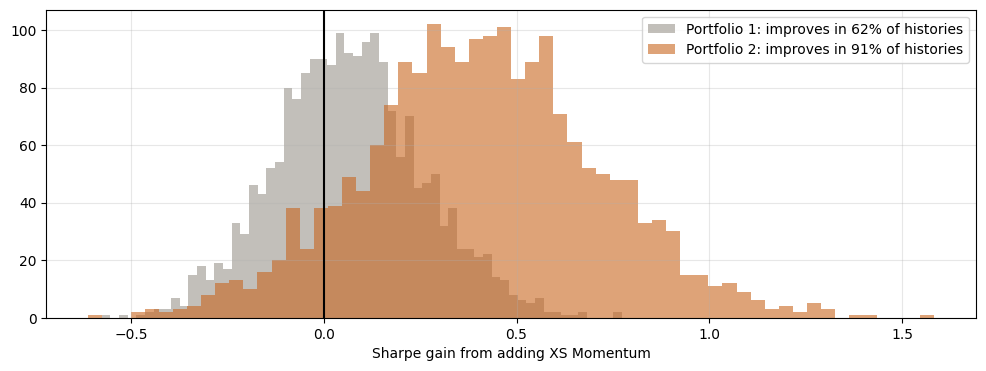

In [6]:
def paired_bootstrap(before, after, block=63, n=2000, seed=0):
    """Sharpe(after) - Sharpe(before) on the same resampled days, n times."""
    a, b, rng, out = before.values, after.values, np.random.default_rng(seed), []
    for _ in range(n):
        starts = rng.integers(0, len(a) - block, len(a) // block + 1)          # random block starts
        i = np.concatenate([np.arange(s, s + block) for s in starts])[:len(a)]   # with replacement
        out.append(sharpe(pd.Series(b[i])) - sharpe(pd.Series(a[i])))
    return np.array(out)

tests, boots = {}, {}
for name, P in BOOKS.items():
    df, cols = DF[name], list(P.columns)
    before, after = equal_risk(df[cols]), equal_risk(df[cols + ["XS Momentum"]])
    boots[name] = paired_bootstrap(before, after)
    tests[name] = {"Sharpe gain": sharpe(after) - sharpe(before),
                   "book improves in % of histories": (boots[name] > 0).mean() * 100}
print(pd.DataFrame(tests).round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
for name, col in [("Portfolio 1", GREY), ("Portfolio 2", ORANGE)]:
    ax.hist(boots[name], bins=60, alpha=.6, color=col, label=f"{name}: improves in {(boots[name] > 0).mean():.0%} of histories")
ax.axvline(0, color="black", lw=1.5); ax.set_xlabel("Sharpe gain from adding XS Momentum"); ax.legend(); plt.show()

**Read it.** Portfolio 1: the book improves in about six histories out of ten. A coin flip. Portfolio 2: nine out of ten. Same candidate, two verdicts.

*Going further (optional).* The same question can be asked with a regression of the candidate on the book: the intercept α is the part of its return the book does not explain, and α > 0 is exactly the marginal Sharpe rule. Its Newey-West t-stat gives 1.16 (Portfolio 1) and 2.28 (Portfolio 2). Same conclusion; the bootstrap is simpler to read.

## 6. Adding over time: when would you have known?

A book grows one strategy at a time, so the decision is taken at a date, with the data you had at that date. No train/test split here: equal risk weights fit nothing, so there is nothing to overfit. The strategy itself was already tested out of sample in Section 2.

Below, the bootstrap redone at the end of every quarter, using only the past (takes about a minute).

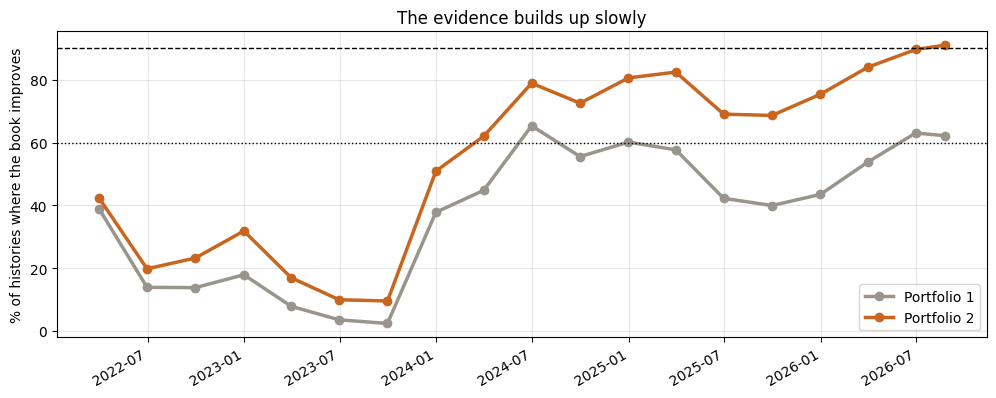

            Portfolio 1  Portfolio 2
2024-12-31         60.0         81.0
2025-03-31         58.0         82.0
2025-06-30         42.0         69.0
2025-09-30         40.0         69.0
2025-12-31         44.0         75.0
2026-03-31         54.0         84.0
2026-06-30         63.0         90.0
2026-08-24         62.0         91.0


In [7]:
quarters = pd.date_range("2022-03-31", DF["Portfolio 1"].index[-1], freq="QE").append(DF["Portfolio 1"].index[-1:])
path = {}
for name, P in BOOKS.items():
    df, cols = DF[name], list(P.columns)
    path[name] = pd.Series({q: (paired_bootstrap(equal_risk(df[:q][cols]), equal_risk(df[:q][cols + ["XS Momentum"]])) > 0).mean() * 100
                            for q in quarters})
path = pd.DataFrame(path)

ax = path.plot(color=[GREY, ORANGE], lw=2.5, marker="o")
ax.axhline(90, color="black", ls="--", lw=1); ax.axhline(60, color="black", ls=":", lw=1)
ax.set_ylabel("% of histories where the book improves"); ax.set_title("The evidence builds up slowly"); plt.show()
print(path.round(0).tail(8).to_string())

**The procedure** (also in `4 Portfolio/Portfolio Checklist Template`)
1. The strategy has passed its own tests (Section 2). We do not re-test the edge here.
2. At the decision date, take the common history with the book, past data only.
3. Check the hurdle, on average and in the book's worst months.
4. Bootstrap: the book improves in **≥ 90 %** of histories → admit (at half weight, lesson 3.4). **60 to 90 %** → on paper, re-test every quarter. **Below 60 %** → no.
5. Write the decision and the date in the Strategy Table.

Crypto XS Momentum: on paper for Portfolio 1 (62 %), admitted for Portfolio 2 (91 %, above 90 % since mid-2026).

# Part 3 · Combine simply (lesson 3.3)

## 7. Equal risk weights, then one multiplier

Each strategy is scaled to the same volatility and gets the same share of risk. The book is then scaled back up to its target with the IDM, as in lesson 2.6, but between strategies instead of between coins.

In [8]:
d = DF["Portfolio 1"]
def idm(df, w):
    w = np.asarray(w, float); w = w / w.sum()
    return 1 / np.sqrt(w @ df.corr().values @ w)

for cols in [["Carry", "Momentum", "Low vol"], ["Carry", "Momentum", "Low vol", "XS Momentum"]]:
    n = len(cols)
    print(f"{n} strategies, equal risk: Sharpe {sharpe(equal_risk(d[cols])):.2f}, IDM {idm(d[cols], [1] * n):.2f}")

3 strategies, equal risk: Sharpe 1.61, IDM 2.06
4 strategies, equal risk: Sharpe 1.61, IDM 2.08


## 8. The trap of fine optimisation

Fit the best weights (maximum Sharpe) on the first half, apply them to the second half. Compare with plain equal weights.

In [9]:
cut = "2023-12-31"
IS, OOS = d[:cut], d[cut:]
z = IS / IS.std()
w = np.clip(np.linalg.solve(np.cov(z.T.values), z.mean().values), 0, None)
w_opt = pd.Series(w / w.sum(), index=d.columns)
w_eq = pd.Series(1 / 4, index=d.columns)

scaled = d / IS.std()                               # vol known at the cut date
res = {}
for name, w in [("equal weights", w_eq), ("optimised on the first half", w_opt)]:
    r = (scaled * w).sum(axis=1)
    res[name] = {"first half (fitted)": sharpe(r[:cut]), "second half (unseen)": sharpe(r[cut:])}
print("optimised weights:", w_opt.round(2).to_dict())
print(pd.DataFrame(res).T.round(2).to_string())

optimised weights: {'Carry': 0.18, 'Momentum': 0.11, 'Low vol': 0.47, 'XS Momentum': 0.24}
                             first half (fitted)  second half (unseen)
equal weights                               0.93                  2.08
optimised on the first half                 1.15                  1.66


**Read it.** The optimiser wins where it was fitted and loses where it was not. With a few years of data, the weights it finds are mostly noise. Equal risk weights are not lazy, they are robust.

## 9. Two strategies of the same family share one budget

Add XS Momentum at a full quarter, and half of the book's risk sits in momentum (Momentum + XS Momentum). Simple fix: give each **family** an equal budget, and split it inside the family.

In [10]:
families = {"Carry": "carry", "Momentum": "momentum", "Low vol": "low vol", "XS Momentum": "momentum"}
def risk_share(w):
    w = pd.Series(w); return (w / w.sum()).groupby(families).sum()

plans = {"3 strategies": {"Carry": 1/3, "Momentum": 1/3, "Low vol": 1/3},
         "4 equal": {"Carry": 1/4, "Momentum": 1/4, "Low vol": 1/4, "XS Momentum": 1/4},
         "family budget": {"Carry": 1/3, "Momentum": 1/6, "Low vol": 1/3, "XS Momentum": 1/6}}
rows = {}
for name, w in plans.items():
    w = pd.Series(w)
    r = (d[w.index] / d[w.index].std() * w).sum(axis=1)
    rows[name] = {"Sharpe": sharpe(r), "momentum share of risk %": risk_share(w)["momentum"] * 100}
print(pd.DataFrame(rows).T.round(2).to_string())

               Sharpe  momentum share of risk %
3 strategies     1.61                     33.33
4 equal          1.61                     50.00
family budget    1.61                     33.33


**Read it.** Same Sharpe, but the family budget keeps momentum at a third of the book instead of half. That is the line to fill in the Strategy Table: strategy, family, weight.

# Part 4 · Keep the portfolio alive (lesson 3.4)

## 10. A new strategy enters at half weight

The backtest is the best case. Live, a strategy starts at half its target weight, and moves to full weight only if it behaves as its sheet predicted (lesson 3.5 says how to check). Here, Portfolio 2 with XS Momentum at 0, half and full weight.

In [11]:
d2 = DF["Portfolio 2"]

def book_sharpe(df, wx):
    w = pd.Series({"Carry": 1.0, "Low vol": 1.0, "XS Momentum": wx})
    return sharpe((df[w.index] / d2[w.index].std() * w).sum(axis=1))

print(pd.Series({name: book_sharpe(d2, wx) for name, wx in [("without", 0), ("half weight", .5), ("full weight", 1)]}).round(2).to_string())

without        1.07
half weight    1.34
full weight    1.38


**Read it.** Half weight gives up a little Sharpe (1.34 against 1.38). That is the price of not betting fully on a backtest.

Now the other side of the bet. We do not know if the edge is real. So we replay the same book in three worlds: XS behaves like its backtest, XS has no edge (its returns shifted down to a Sharpe of 0), XS loses (Sharpe −0.5). Same days, same volatility, only the average moves.

In [12]:
x = d2["XS Momentum"]
worlds = {"works (as backtested)": x,
          "edge gone (Sharpe 0)": x - x.mean(),
          "loses (Sharpe -0.5)": x - x.mean() - 0.5 * x.std() / np.sqrt(PPY)}
rows = {}
for name, xw in worlds.items():
    dw = d2.assign(**{"XS Momentum": xw})
    rows[name] = {k: book_sharpe(dw, wx) for k, wx in [("without", 0), ("half", .5), ("full", 1)]}
print(pd.DataFrame(rows).T.round(2).to_string())

                       without  half  full
works (as backtested)     1.07  1.34  1.38
edge gone (Sharpe 0)      1.07  1.02  0.85
loses (Sharpe -0.5)       1.07  0.80  0.49


**Read it.** If XS works, half weight costs 0.04 of Sharpe. If it does not, half weight saves 0.17 to 0.31. Small cost when right, big saving when wrong: that is why a new strategy enters at half.

## 11. Risk at book level

Three numbers to watch for the whole book, not for each strategy:
- the **IDM**, which multiplies every strategy up, so it must be capped;
- a **loss limit** for the book, written in advance;
- **correlations in bad days**. In many books they jump in a crisis. Measure yours.

Our book from now on: Portfolio 2 with XS Momentum at half weight.

In [13]:
w = pd.Series({"Carry": 1.0, "Low vol": 1.0, "XS Momentum": 0.5})
bk = (d2[w.index] / d2[w.index].std() * w).sum(axis=1)
bk = bk / (bk.std() * np.sqrt(PPY)) * 0.10                     # book at 10 % vol

c = d2.corr().values; w3 = np.ones(3) / 3
print(f"IDM at target weights (1/3 each): {1 / np.sqrt(w3 @ c @ w3):.2f}  -> if everything moved together, book vol = {0.10 / np.sqrt(w3 @ c @ w3):.0%}")
print(f"worst book drawdown (10 % vol): {drawdown(bk).min():.1%}  -> loss limit at 1.5x: {1.5 * drawdown(bk).min():.1%}")

def mean_pair_corr(df):
    c = df.corr().values; return c[np.triu_indices(len(c), 1)].mean()
print(f"average correlation between strategies, all days        : {mean_pair_corr(d2):+.2f}")
print(f"average correlation between strategies, book's worst 10 %: {mean_pair_corr(d2[bk < bk.quantile(.1)]):+.2f}")

IDM at target weights (1/3 each): 2.14  -> if everything moved together, book vol = 21%
worst book drawdown (10 % vol): -9.1%  -> loss limit at 1.5x: -13.7%
average correlation between strategies, all days        : -0.17
average correlation between strategies, book's worst 10 %: -0.36


**Read it.** The IDM is about 2.1: every strategy is scaled up twice because they diversify. If one day they all moved together, the book would run at about 21 % volatility instead of 10 %. Cap it. In this book, correlations do not rise on bad days, they fall: Low vol keeps pulling the other way. Do not assume it, measure it, and measure it again every month.

# Part 5 · Is the edge fading? (lesson 3.5)

## 12. Three performance tests, written before going live

Live returns are noisy. A bad quarter proves nothing. So we compare live results to what the backtest **allows**, not to what it promised on average:
1. **Rolling 12-month Sharpe** against the range the backtest produces (5th percentile, block bootstrap).
2. **Drawdown** against the worst backtest drawdown: 1.5× watch and halve, 2× cut.
3. **CUSUM**: adds up, period after period, how far live returns fall short of the backtest mean. It sees a slow leak that no single bad month shows. Alarm level calibrated on the backtest itself (5 % false alarms).

Two strategies, one framed as live from January 2025: Crypto XS Momentum and FOMC Drift.

In [14]:
def cusum(live, ref):
    """Downward CUSUM of live returns against the backtest mean (in backtest standard deviations)."""
    mu, sd = ref.mean(), ref.std(); k = 0.5 * mu / sd
    s, out = 0.0, []
    for v in (live - mu) / sd:
        s = min(0.0, s + v + k); out.append(s)
    return pd.Series(out, index=live.index)

def cusum_alarm(ref, n_live, n=5000, q=5, seed=0):
    """Level that a strategy behaving like its backtest crosses only q % of the time."""
    rng = np.random.default_rng(seed)
    return np.percentile([cusum(pd.Series(rng.choice(ref.values, n_live)), ref).min() for _ in range(n)], q)

def sharpe_band(ref, window, ppy, block=21, n=5000, seed=1):
    """5th percentile of the rolling-window Sharpe the backtest can produce."""
    a, rng, out = ref.values, np.random.default_rng(seed), []
    for _ in range(n):
        st = rng.integers(0, len(a) - block, window // block + 1)
        s = np.concatenate([a[i:i + block] for i in st])[:window]
        out.append(s.mean() / s.std() * np.sqrt(ppy))
    return np.percentile(out, 5)

## 13. Crypto XS Momentum, live from 2025

rolling 12m Sharpe: lowest live 0.10, alarm below -0.76
drawdown: worst live -15.6%, backtest worst -22.8% (halve at -34.2%, cut at -45.6%)
CUSUM (monthly): lowest live -3.53, alarm at -6.67


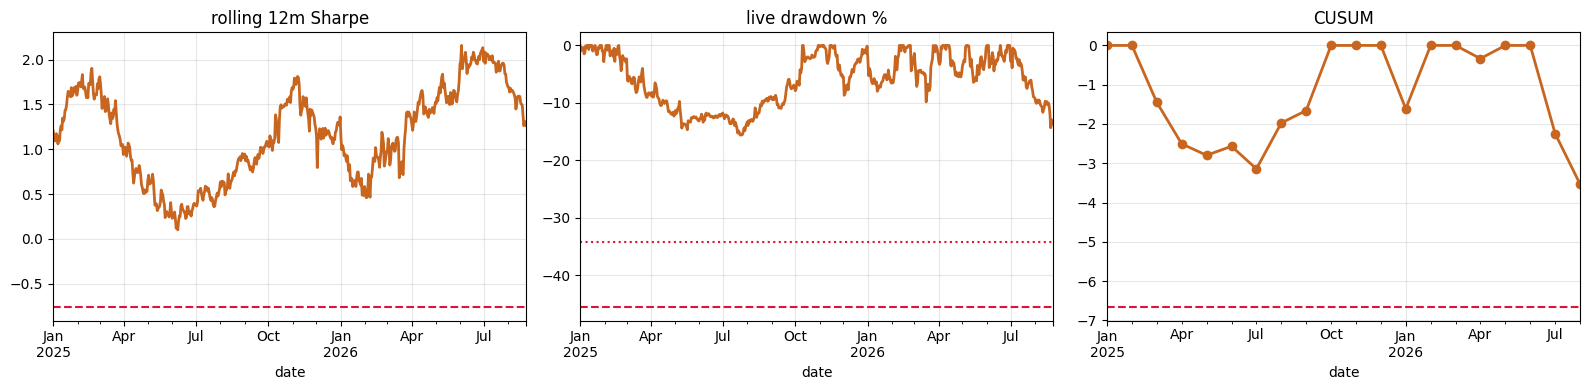

In [15]:
LIVE = "2025-01-01"
bt, lv = XS[:"2024"], XS[LIVE:]
m_bt, m_lv = bt.resample("ME").sum(), lv.resample("ME").sum()
band = sharpe_band(bt, 365, PPY)
roll = XS.rolling(365).apply(sharpe)[LIVE:]
worst = drawdown(bt).min()
alarm = cusum_alarm(m_bt, len(m_lv))
cs = cusum(m_lv, m_bt)

print(f"rolling 12m Sharpe: lowest live {roll.min():.2f}, alarm below {band:.2f}")
print(f"drawdown: worst live {drawdown(lv).min():.1%}, backtest worst {worst:.1%} (halve at {1.5 * worst:.1%}, cut at {2 * worst:.1%})")
print(f"CUSUM (monthly): lowest live {cs.min():.2f}, alarm at {alarm:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
roll.plot(ax=ax[0], color=ORANGE, lw=2); ax[0].axhline(band, color="crimson", ls="--"); ax[0].set_title("rolling 12m Sharpe")
(drawdown(lv) * 100).plot(ax=ax[1], color=ORANGE, lw=2)
for k_, ls in [(1.5, ":"), (2, "--")]: ax[1].axhline(k_ * worst * 100, color="crimson", ls=ls)
ax[1].set_title("live drawdown %")
cs.plot(ax=ax[2], color=ORANGE, lw=2, marker="o"); ax[2].axhline(alarm, color="crimson", ls="--"); ax[2].set_title("CUSUM")
plt.tight_layout(); plt.show()

**Read it.** All three tests stay green. A quiet strategy is not a proven one, but nothing says the edge is fading.

## 14. FOMC Drift, live from 2025: point-in-time replay

Trades up to 2024 are the backtest. Every trade after that is checked against the levels written before. Displayed at 10 % volatility, the leverage fixed in notebook 01.

In [16]:
F = pd.read_csv(f"{DATA}/fomc_drift_trades.csv", index_col=0, parse_dates=True)["basket_return"]
LEV = 12.06                                         # 10 % vol, from notebook 01
fr = F * LEV
f_bt, f_lv = fr[:"2024"], fr[LIVE:]
f_worst = drawdown(f_bt).min()
f_alarm = cusum_alarm(f_bt, len(f_lv))
f_cs = cusum(f_lv, f_bt)
f_dd = drawdown(fr)[LIVE:]                          # drawdown of the whole equity curve, seen live

log = pd.DataFrame({"trade %": f_lv * 100, "drawdown %": f_dd * 100, "CUSUM": f_cs})
status, out = "live", []
for t, row in log.iterrows():
    if status != "cut":
        if row["drawdown %"] < -20:                         status = "cut"     # kill written in the sheet
        elif row["drawdown %"] < 1.5 * f_worst * 100:       status = "halved"
        elif row["CUSUM"] < f_alarm and status == "live":   status = "watch"
    out.append(status)
log["status after the trade"] = out
print(f"backtest worst drawdown {f_worst:.1%} -> halve at {1.5 * f_worst:.1%}; sheet kill at -20 %; CUSUM alarm {f_alarm:.2f}")
print(log.round(2).to_string())

backtest worst drawdown -13.0% -> halve at -19.4%; sheet kill at -20 %; CUSUM alarm -5.01
                     trade %  drawdown %  CUSUM status after the trade
announce_utc                                                          
2025-01-29 19:00:00    -1.95       -4.75  -0.76                   live
2025-03-19 18:00:00    -6.50      -10.94  -2.84                   live
2025-05-07 18:00:00    -3.39      -13.95  -4.02                   live
2025-06-18 18:00:00     0.76      -13.30  -3.99                   live
2025-07-30 18:00:00    -6.03      -18.53  -5.94                  watch
2025-09-17 18:00:00    -1.78      -19.97  -6.65                 halved
2025-10-29 18:00:00    -0.31      -20.23  -6.94                    cut
2025-12-10 19:00:00     2.45      -18.27  -6.42                    cut
2026-01-28 19:00:00    -1.46      -19.46  -7.04                    cut
2026-03-18 18:00:00    -3.96      -22.66  -8.39                    cut
2026-04-29 18:00:00    -4.62      -26.23  -9.92           

**Read it.** The CUSUM sees the leak first, in July 2025: watch. The drawdown passes 1.5× the worst backtest drawdown in September: halve. The kill written in the sheet (−20 %) fires on 2025-10-29: cut. The trades after it still lose. None of these levels was chosen after the fact.

/tmp/ipykernel_425/588301533.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[1].plot(t, eq[t], "o", color="crimson", ms=9)


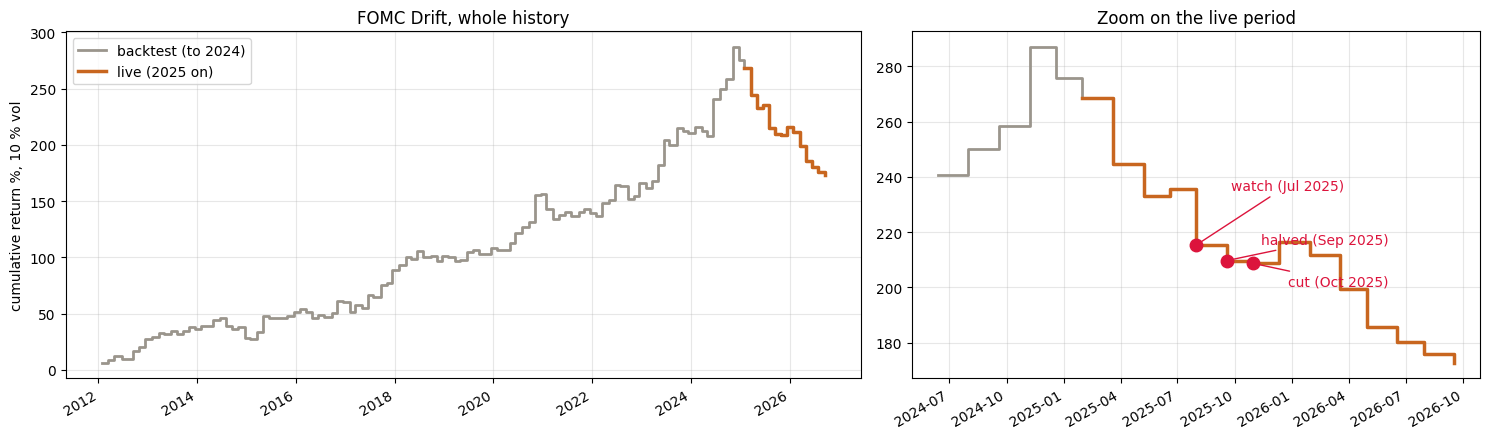

In [17]:
events = log.groupby("status after the trade", sort=False).apply(lambda g: g.index[0])
eq = ((1 + fr).cumprod() - 1) * 100
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[1.4, 1])
eq.plot(ax=ax[0], color=GREY, lw=2, drawstyle="steps-post", label="backtest (to 2024)")
eq[LIVE:].plot(ax=ax[0], color=ORANGE, lw=2.5, drawstyle="steps-post", label="live (2025 on)")
ax[0].set_ylabel("cumulative return %, 10 % vol"); ax[0].set_xlabel(""); ax[0].legend(); ax[0].set_title("FOMC Drift, whole history")
z = eq["2024-06":]
z.plot(ax=ax[1], color=GREY, lw=2, drawstyle="steps-post"); eq[LIVE:].plot(ax=ax[1], color=ORANGE, lw=2.5, drawstyle="steps-post")
for k_, (lab, t) in enumerate(events.drop("live", errors="ignore").items()):
    ax[1].plot(t, eq[t], "o", color="crimson", ms=9)
    ax[1].annotate(f"{lab} ({t:%b %Y})", (t, eq[t]), xytext=(25, 40 - 28 * k_), textcoords="offset points", color="crimson",
                   arrowprops=dict(arrowstyle="-", color="crimson"))
ax[1].set_title("Zoom on the live period"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 15. The ship of Theseus

One last experiment, on simulated strategies so we can see 16 years. A research process feeds a library: a new validated strategy every 9 months. Every strategy earns a Sharpe of 0.8 while its edge lasts, then loses (Sharpe −0.5) once the edge is gone. Edges last between 2 and 9 years, and nobody knows when one dies.

Two books start with the same four strategies:
- **frozen**: never adds, never cuts;
- **alive**: adds each new strategy at half weight for a year, then full weight, and cuts any strategy whose CUSUM crosses its alarm.

The assumptions are ours, the mechanics are the course's.

In [18]:
def simulate_book(seed, years=16, n0=4, every=9, sr_on=0.8, sr_off=-0.5, life=(2, 9), rho=0.2, h=8.0):
    rng = np.random.default_rng(seed); M = years * 12; vol = 0.10 / np.sqrt(12)
    starts = [0] * n0 + list(range(every, M, every)); N = len(starts)
    deaths = [s + int(rng.uniform(*life) * 12) for s in starts]
    corr = np.full((N, N), rho); np.fill_diagonal(corr, 1)
    E = rng.standard_normal((M, N)) @ np.linalg.cholesky(corr).T
    R = np.array([np.where(np.arange(M) < deaths[j], sr_on, sr_off) * 0.10 / 12 for j in range(N)]).T + E * vol
    mu, k = sr_on * 0.10 / 12, 0.5 * sr_on * 0.10 / 12 / vol
    state = np.zeros((M, N), int)                    # 0 not yet, 1 half weight, 2 full, 3 cut
    cus, W = np.zeros(N), np.zeros((M, N))
    for t in range(M):
        for j in range(N):
            if t < starts[j]: continue
            if t > 0 and state[t - 1, j] == 3: state[t, j] = 3; continue
            state[t, j] = 2 if (j < n0 or t - starts[j] >= 12) else 1
        w = np.select([state[t] == 2, state[t] == 1], [1.0, 0.5], 0.0)
        if w.sum():
            w = w / w.sum(); W[t] = w / np.sqrt(w @ corr @ w)        # equal risk x IDM
        for j in np.where((state[t] == 1) | (state[t] == 2))[0]:
            cus[j] = min(0.0, cus[j] + (R[t, j] - mu) / vol + k)
            if cus[j] < -h: state[t, j] = 3                            # cut from next month
    w0 = np.full(n0, 1 / n0); frozen = R[:, :n0] @ w0 / np.sqrt(w0 @ corr[:n0, :n0] @ w0)
    idx = pd.date_range("2010-01-31", periods=M, freq="ME")
    return dict(alive=pd.Series((W * R).sum(1), idx), frozen=pd.Series(frozen, idx), state=state, deaths=deaths, starts=starts, idx=idx)

# 40 different worlds: what happens on average
avg = pd.DataFrame([{"alive": sharpe(o["alive"], 12), "frozen": sharpe(o["frozen"], 12)}
                    for o in (simulate_book(s) for s in range(40))])
print("Sharpe over 16 years, mean of 40 simulated worlds:"); print(avg.mean().round(2).to_string())

SIM = simulate_book(24)                               # one world, the one in the animation
print(f"\nthis world: alive {sharpe(SIM['alive'], 12):.2f}, frozen {sharpe(SIM['frozen'], 12):.2f}, "
      f"original strategies still in the book at the end: {((SIM['state'][-1, :4] == 1) | (SIM['state'][-1, :4] == 2)).sum()} of 4")

Sharpe over 16 years, mean of 40 simulated worlds:
alive     0.98
frozen   -0.11

this world: alive 1.12, frozen -0.33, original strategies still in the book at the end: 0 of 4


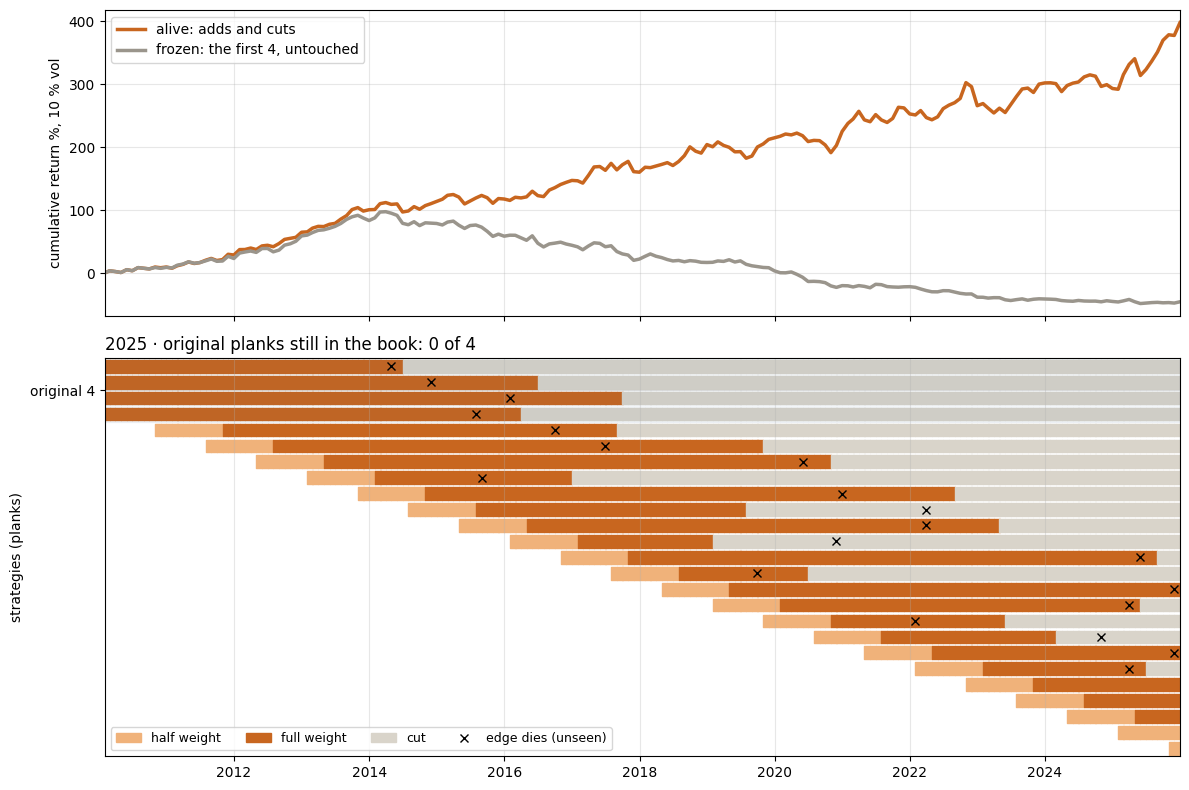

In [19]:
from matplotlib.patches import Patch

st, idx = SIM["state"], SIM["idx"]
ca, cf = ((1 + SIM["alive"]).cumprod() - 1) * 100, ((1 + SIM["frozen"]).cumprod() - 1) * 100
COL = {1: "#f0b27a", 2: ORANGE, 3: "#d9d4ca"}
N, M = st.shape[1], st.shape[0]

def draw(t):
    a1.clear(); a2.clear()
    a1.plot(idx[:t + 1], ca[:t + 1], color=ORANGE, lw=2.5, label="alive: adds and cuts")
    a1.plot(idx[:t + 1], cf[:t + 1], color=GREY, lw=2.5, label="frozen: the first 4, untouched")
    a1.set_xlim(idx[0], idx[-1]); a1.set_ylim(min(cf.min(), ca.min()) - 20, ca.max() + 20)
    a1.set_ylabel("cumulative return %, 10 % vol"); a1.legend(loc="upper left"); a1.grid(alpha=.3)
    for j in range(N):
        s = st[:t + 1, j]
        for v in (1, 2, 3):
            on = np.where(s == v)[0]
            if len(on): a2.broken_barh([(idx[i], pd.Timedelta(days=31)) for i in on], (j - .4, .8), color=COL[v])
        if SIM["deaths"][j] <= t: a2.plot(idx[SIM["deaths"][j]], j, marker="x", color="black", ms=6)
    a2.set_ylim(N - .5, -.5); a2.set_yticks([1.5]); a2.set_yticklabels(["original 4"])
    a2.axhspan(-.5, 3.5, color=BLUE, alpha=.06)
    a2.set_ylabel("strategies (planks)"); a2.grid(alpha=.3)
    left = ((st[t, :4] == 1) | (st[t, :4] == 2)).sum()
    a2.set_title(f"{idx[t]:%Y} · original planks still in the book: {left} of 4", loc="left")
    a2.legend(handles=[Patch(color=COL[1], label="half weight"), Patch(color=COL[2], label="full weight"),
                       Patch(color=COL[3], label="cut"), plt.Line2D([], [], marker="x", color="black", ls="", label="edge dies (unseen)")],
              loc="lower left", ncol=4, fontsize=9)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[1, 1.3], sharex=True)
draw(M - 1); plt.tight_layout(); plt.show()

The same 16 years as an animation, saved to `figures/book_theseus.gif`.

In [20]:
from matplotlib.animation import FuncAnimation, PillowWriter
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[1, 1.3], sharex=True)
frames = list(range(0, M, 2)) + [M - 1] * 15
anim = FuncAnimation(fig, draw, frames=frames)
anim.save("figures/book_theseus.gif", writer=PillowWriter(fps=8))
plt.close(fig)

**Read it.** Every plank of the original ship is gone, and the ship still sails. The frozen book holds on while its four edges live, then sinks with them. The alive book cuts some good strategies by mistake too: that costs little when the library keeps producing.

This is why the whole course exists: research fills the library (Section 2), the rule lets strategies in (3.2), equal weights hold them together (3.3), and monitoring lets them out (3.5).

## 16. Your exercise

Apply sections 3 to 6 to your own strategy from the Section 2 exercises, against Portfolio 1. Fill the checklist (`4 Portfolio/Portfolio Checklist Template`): hurdle, bad-times correlation, bootstrap, decision.